**DIAMOND A-DC PBSHM Coding Challenge**

---

- **Name**: Ernest Toochukwu, Samuel
- **Date**: 02-04-2026

---
#Task 3 - Unsupervised or anomaly-based baseline
Implement at least one simpler exploratory method that does not rely on a graph neural network.

Examples include:

- clustering on structure-level summaries
PCA or other embedding plus visual separation

- Nearest-neighbor anomaly scoring

- isolation forest or another anomaly detector

Discuss whether damaged structures appear separable and what the limitations of these simpler methods are.

In [ ]:
"""
Importing necessary libraries and setting up the environment
for data analysis and visualization.
"""

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score
from sklearn.cluster import KMeans


plt.style.use('seaborn-v0_8')


# -----------------------------
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_recall_curve, auc
from sklearn.ensemble import IsolationForest
import numpy as np # Ensure numpy is imported
import matplotlib.pyplot as plt # Ensure matplotlib is imported
import seaborn as sns # Ensure seaborn is imported


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#-//--------- Data Loading and Preprocessing ---------//-

with open('/content/drive/MyDrive/PBSHM-challenge/structures_measurements.json') as f:
    structures = json.load(f)

labels = pd.read_csv('/content/drive/MyDrive/PBSHM-challenge/structure_labels.csv')

# Load population graph
edges = pd.read_csv("/content/drive/MyDrive/PBSHM-challenge/population_edges_geometry.csv")
weights = pd.read_csv("/content/drive/MyDrive/PBSHM-challenge/population_edge_weights_geometry.csv")


#nodes_df.head()
structure_df.head()

,structure_id,n_storeys,total_height,damaged,frequency_std_times_total_height,frequency_Hz_squared_std,inverse_height_cubed_std,inverse_total_height_cubed
0,0,6,24.905,0,62.890163,23.539426,0.006237,0.000065
1,1,5,19.219,0,38.811851,22.900213,0.009751,0.000141
2,2,8,32.077,0,37.989516,12.433084,0.008727,0.000030
3,3,6,22.181,1,56.705535,25.117397,0.002201,0.000092
4,4,7,29.248,1,68.461296,25.170422,0.006831,0.000040


# Data Import and processing
- Import all datafram and variables from Task1

In [ ]:
# Run and capture all needed variables from Task1 and Task2

%run /content/drive/MyDrive/PBSHM-challenge/pbshm_tasks/task1_explore_population.ipynb
%run /content/drive/MyDrive/PBSHM-challenge/pbshm_tasks/task2_structure_bl_model.ipynb


In [ ]:
## Inspect available funtions and variables
# print(list(globals().keys()))


## Funtion Definitions

In [ ]:

def run_isolation_forest_cv_analysis(features_df, target_series, n_splits=3, contamination=0.3, random_state=50, percentile_threshold=70):
    """
    Performs K-Fold cross-validation with an Isolation Forest model,
    prints results, and visualizes the best performing fold.

    Args:
        features_df (pd.DataFrame): DataFrame containing the features.
        target_series (pd.Series): Series containing the target labels (0 for healthy, 1 for damaged).
        n_splits (int): Number of folds for K-Fold cross-validation.
        contamination (float): The proportion of outliers in the data set.
        random_state (int): Seed for random number generators for reproducibility.
        percentile_threshold (int): Percentile to use for setting the anomaly threshold.

    Returns:
        tuple: (list of dict, dict) A list of fold results and the data from the best fold.
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    fold_results = []
    best_roc_auc = -1
    best_fold_data = None

    print(f"--- Starting Isolation Forest Cross-Validation with {n_splits} folds ---")

    for fold, (train_index, test_index) in enumerate(kf.split(features_df)):
        X_train_fold, X_test_fold = features_df.iloc[train_index], features_df.iloc[test_index]
        y_train_fold, y_test_fold = target_series.iloc[train_index], target_series.iloc[test_index]

        iso_model_fold = IsolationForest(n_estimators=100, contamination=contamination, random_state=random_state)
        iso_model_fold.fit(X_train_fold)

      # We negate it so that 'Anomaly Score' is higher for anomalies
        test_scores_fold = -iso_model_fold.decision_function(X_test_fold)
        threshold_fold = np.percentile(test_scores_fold, percentile_threshold)

        y_pred_fold = (test_scores_fold > threshold_fold).astype(int)

        roc_auc_fold = roc_auc_score(y_test_fold, test_scores_fold)
        accuracy_fold = accuracy_score(y_test_fold, y_pred_fold)
        f1_score_fold = f1_score(y_test_fold, y_pred_fold)

        precision_fold, recall_fold, _ = precision_recall_curve(y_test_fold, test_scores_fold)
        pr_auc_fold = auc(recall_fold, precision_fold)

        fold_results.append({
            'fold': fold + 1,
            'accuracy': accuracy_fold,
            'f1_score': f1_score_fold,
            'roc_auc': roc_auc_fold,
            'pr_auc': pr_auc_fold
        })

        if roc_auc_fold > best_roc_auc:
            best_roc_auc = roc_auc_fold
            best_fold_data = {
                'X_test': X_test_fold,
                'y_test': y_test_fold,
                'test_scores': test_scores_fold,
                'threshold': threshold_fold,
                'metrics': {'accuracy': accuracy_fold, 'f1_score': f1_score_fold, 'roc_auc': roc_auc_fold, 'pr_auc': pr_auc_fold}
            }

    print("\n--- Isolation Forest Cross-Validation Results ---")
    for res in fold_results:
        print(f"Fold {res['fold']}: Accuracy={res['accuracy']:.3f}, F1 Score={res['f1_score']:.3f}, ROC-AUC={res['roc_auc']:.3f}")

    if best_fold_data:
        print(f"\n--- Best Performing Fold (based on ROC-AUC) ---")
        print(f"Accuracy: {best_fold_data['metrics']['accuracy']:.3f}")
        print(f"F1 Score: {best_fold_data['metrics']['f1_score']:.3f}")
        print(f"ROC-AUC:  {best_fold_data['metrics']['roc_auc']:.3f}")
        # print(f"PR-AUC:   {best_fold_data['metrics']['pr_auc']:.3f}")

        # Visualization of the Best Performing Model
        plt.figure(figsize=(10, 6))

        sns.scatterplot(
            x=best_fold_data['X_test']['Freq_norm'],
            y=best_fold_data['test_scores'],
            hue=best_fold_data['y_test'].map({0: 'Healthy', 1: 'Damaged'}),
            palette={'Healthy': '#4C72B0', 'Damaged': '#C44E52'},
            style=best_fold_data['y_test'].map({0: 'Healthy', 1: 'Damaged'}),
            markers={'Healthy': 'o', 'Damaged': 'X'},
            s=100,
            alpha=0.8
        )

        plt.axhline(best_fold_data['threshold'], color='black', linestyle='--', label='Anomaly Threshold')
        plt.title(f"Isolation Forest: Best Performing Fold (ROC-AUC: {best_fold_data['metrics']['roc_auc']:.3f})")
        plt.xlabel("Frequency Std (Normalized)")
        plt.ylabel("Anomaly Score (Model Output)")
        plt.legend(title="Condition", bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.tight_layout()
        plt.show()
    else:
        print("No best fold data available. This might happen if cross-validation failed.")

    return fold_results, best_fold_data



import matplotlib.patches as patches
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, f1_score, roc_auc_score, precision_recall_curve, auc

def run_kmeans_anomaly_detection(features_df, target_series, n_clusters=3, n_init=100, test_size=0.25, random_state=50, percentile_threshold=75):
    """
    Performs K-Means clustering for anomaly detection on structural features.

    This function splits the data, fits K-Means on the training set, and then
    uses the distances of test samples to their assigned cluster centers to
    identify anomalies based on a percentile threshold. It reports various
    classification metrics and visualizes the results.

    Args:
        features_df (pd.DataFrame): DataFrame containing the features (e.g., 'Freq_norm', 'Height_norm').
        target_series (pd.Series): Series containing the binary target labels (0 for healthy, 1 for damaged).
        n_clusters (int, optional): The number of clusters to form. Defaults to 3.
        n_init (int, optional): Number of times the k-means algorithm is run with different
                               centroid seeds. The final results is the best output of
                               n_init consecutive runs in terms of inertia. Defaults to 100.
        test_size (float, optional): The proportion of the dataset to include in the test split.
                                     Defaults to 0.25.
        random_state (int, optional): Controls the randomness of the data splitting and K-Means
                                      initialization. Defaults to 50.
        percentile_threshold (int, optional): The percentile of distances to cluster centers
                                              above which a sample is classified as an anomaly.
                                              Defaults to 75.

    Returns:
        tuple: A tuple containing:
            - dict: A dictionary of evaluation metrics (accuracy, precision, f1-score, ROC-AUC, PR-AUC).
            - dict: A dictionary containing data used for visualization (X_test, y_test, y_pred_test, threshold, kmeans.cluster_centers_).
    """
    # Prepare Features and Target
    X_unsupervised = features_df.values
    y = target_series.values

    # Split Data
    X_train, X_test, y_train, y_test = train_test_split(X_unsupervised, y, test_size=test_size, random_state=random_state, stratify=y)

    # K-Means on Training Data
    kmeans = KMeans(n_clusters=n_clusters, n_init=n_init, random_state=random_state)
    kmeans.fit(X_train)

    # Anomaly Detection on Test Data
    test_clusters = kmeans.predict(X_test)
    test_centers = kmeans.cluster_centers_[test_clusters]
    test_distances = np.sqrt(np.sum((X_test - test_centers)**2, axis=1))

    # Define anomalies as top 'percentile_threshold'% of distances in the test set
    threshold = np.percentile(test_distances, percentile_threshold)
    y_pred_test = (test_distances > threshold).astype(int)

    # Advanced Metrics
    accuracy = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test, zero_division=0)
    f1 = f1_score(y_test, y_pred_test, zero_division=0)
    roc_auc = roc_auc_score(y_test, test_distances)
    precisions, recalls, _ = precision_recall_curve(y_test, test_distances)
    pr_auc = auc(recalls, precisions)

    metrics = {
        'accuracy': accuracy,
        'precision': precision,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc
    }

    # 6. Reporting
    print("--- Unsupervised K-Means Report ---")
    print(f"Accuracy:  {metrics['accuracy']:.3f}")
    print(f"Precision: {metrics['precision']:.3f}")
    print(f"F1-Score:  {metrics['f1_score']:.3f}")
    print(f"ROC-AUC:   {metrics['roc_auc']:.3f}")
    # print(f"PR-AUC:    {metrics['pr_auc']:.3f}")

    # 7. Visualization with False Negatives highlighted
    plt.figure(figsize=(10, 6))

    # Plot all test structures colored by distance
    scatter = plt.scatter(
        X_test[:, 0],
        X_test[:, 1],
        c=test_distances,
        cmap='viridis',
        s=120,
        edgecolors='k',
        alpha=0.6,
        label='Test structures'
    )
    plt.colorbar(scatter, label='Distance to Cluster Center')

    # Draw circles around cluster centers with the threshold as radius
    for center in kmeans.cluster_centers_:
        circle = patches.Circle(center, threshold, edgecolor='blue', facecolor='none', linestyle='--', linewidth=1, alpha=0.7)
        plt.gca().add_patch(circle)
    plt.plot([], [], 'b--', label=f'{percentile_threshold}% Anomaly Distance Boundary ({threshold:.2f})') # Label for the circles

    # Mark predicted anomalies (Flagged by model)
    anomalies = X_test[y_pred_test == 1]
    plt.scatter(anomalies[:, 0], anomalies[:, 1], s=250, facecolors='none', edgecolors='r', linewidth=2, label='Flagged Anomaly')

    # Mark False Negatives (Damaged but NOT detected as anomaly)
    false_negatives_mask = (y_test == 1) & (y_pred_test == 0)
    fn_points = X_test[false_negatives_mask]
    plt.scatter(fn_points[:, 0], fn_points[:, 1], marker='*', s=150, color='yellow', edgecolors='black', label='Missed Damage (False Negative)')

    plt.xlabel('Normalized Frequency')
    plt.ylabel('Normalized Height')
    plt.title('Unsupervised K-Means: Detection vs. Actual Damage')
    plt.legend(bbox_to_anchor=(1.25, 1), loc='upper left') # Increased x-coordinate for bbox_to_anchor
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

    visualization_data = {
        'X_test': X_test,
        'y_test': y_test,
        'y_pred_test': y_pred_test,
        'threshold': threshold,
        'cluster_centers': kmeans.cluster_centers_
    }

    return metrics, visualization_data


## Import and Process Dataset

In [ ]:
# Call normalize_structure_features function (Task2) and pass structure_df (Task1) as input
structure_norm_df = normalize_structure_features(structure_df)

# Define features and target based on structure_norm_df for later use
features = structure_norm_df.drop(columns=['structure_id', 'damaged'])
target_damaged = structure_norm_df['damaged']


print('\nFeatures for modeling created and its head displayed:')
print(features.head())
print('\nTarget variable created and its head displayed:')
target_damaged.head()


Features for modeling created and its head displayed:
   Freq_norm  Height_norm
0   0.861854     0.684679
1   0.834459     0.313477
2   0.385878     0.300799
3   0.929480     0.589334
4   0.931752     0.770566

Target variable created and its head displayed:


,damaged
0,0
1,0
2,0
3,1
4,1


# Task 3

--- Starting Isolation Forest Cross-Validation with 5 folds ---

--- Isolation Forest Cross-Validation Results ---
Fold 1: Accuracy=0.700, F1 Score=0.571, ROC-AUC=0.750, PR-AUC=0.780
Fold 2: Accuracy=0.500, F1 Score=0.286, ROC-AUC=0.458, PR-AUC=0.516
Fold 3: Accuracy=0.800, F1 Score=0.667, ROC-AUC=0.810, PR-AUC=0.461
Fold 4: Accuracy=0.600, F1 Score=0.000, ROC-AUC=0.111, PR-AUC=0.056
Fold 5: Accuracy=0.600, F1 Score=0.333, ROC-AUC=0.524, PR-AUC=0.519

--- Best Performing Fold (based on ROC-AUC) ---
Accuracy: 0.800
F1 Score: 0.667
ROC-AUC:  0.810
PR-AUC:   0.461


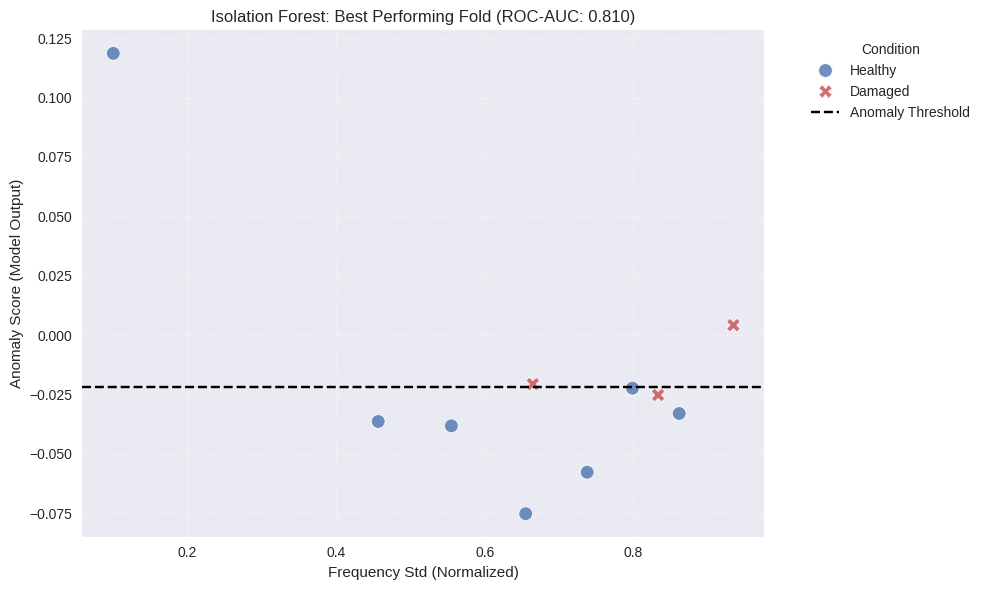

In [ ]:


# Call the function with existing features and target_damaged
# You can modify n_splits, contamination, etc. here if needed.
all_fold_results, best_fold_info = run_isolation_forest_cv_analysis(features, target_damaged, n_splits=5)

### Relationship between Frequency and Anomaly Score

Isolation Forest doesn't look at frequency in isolation; it looks at how 'easy' it is to separate a structure from the rest of the population using both its frequency and its size (storeys).

Kmeans

--- Unsupervised K-Means Report ---
Accuracy:  0.769
Precision: 0.667
F1-Score:  0.571
ROC-AUC:   0.861
PR-AUC:    0.771


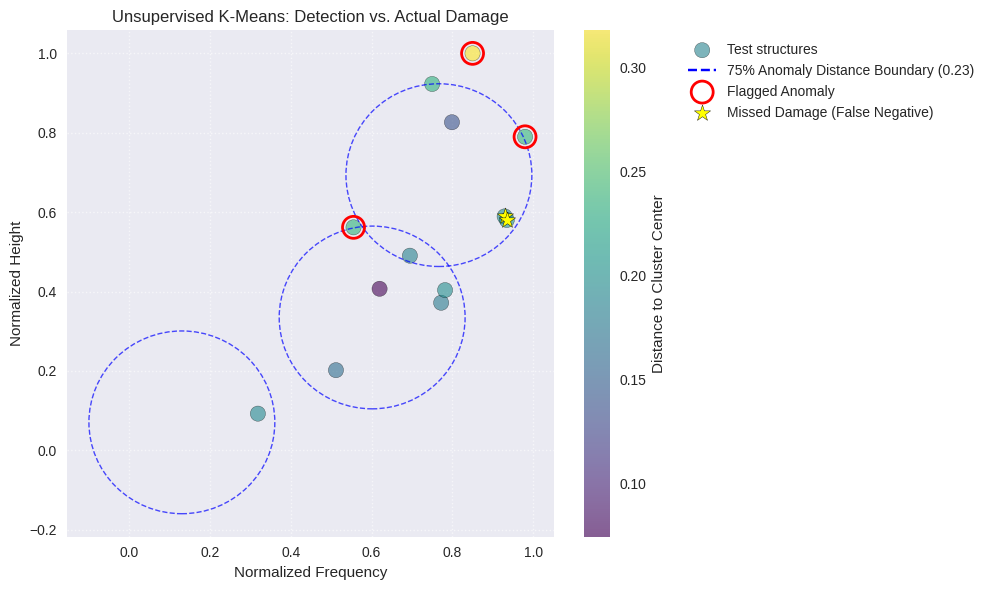

In [ ]:

# Call the function with existing features and target_damaged
kmeans_metrics, kmeans_viz_data = run_kmeans_anomaly_detection(
    features_df=features[['Freq_norm', 'Height_norm']],
    target_series=target_damaged,
    n_clusters=3,
    n_init=100,
    test_size=0.25,
    random_state=50,
    percentile_threshold=75
)

///////////////////////////////////